**ANALISIS DE LA INFLUENCIA LA INFRAESTRUCTURA PÚBLICA SOBRE LA DESIGUALDAD REGIONAL**

El objetivo de este análisis es estimar los efectos de la infraestructura pública sobre la desigualda a nivel regional en el Perú para el período 2004–2023 (empleando para medir la desigualdad, el Indice de Gini -construido para cada región del país-).
El análisis se efectuará empleando la información de la ENAHO para el período mencionado, con la finalidad de disponer de indicadores físicos sobre la infraestructura de transporte, electricidad y telecomunicaciones.
Las demás variables de control a ser utilizadas se obtienen de los Compendios Estadísticos del INEI correspondiente a los años antes mencionado



IMPORTAR DATOS

In [ ]:
import pandas as pd
import numpy as np
import os
from google.colab import drive

try:
    import pyreadstat
except ImportError:
    print("pyreadstat not found. Installing...")
    !pip install pyreadstat
    import pyreadstat
    print("pyreadstat installed and imported successfully.")

# 1. Montar Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 2. Definir la función weighted_mean fuera del bucle para reusabilidad
def weighted_mean(group, column_name, weight_column='factor07'):
    # Evitar división por cero si no hay datos
    mask = group[column_name].notna()
    weights_sum = group.loc[mask, weight_column].sum()
    if weights_sum == 0: return 0
    return (group.loc[mask, column_name] * group.loc[mask, weight_column]).sum() / weights_sum

# 3. Función para calcular el Coeficiente de Gini ponderado
def gini_ponderado(x, w):
    """Calcula el coeficiente de Gini para datos con pesos (factores de expansión)"""
    # Asegurar que los datos estén ordenados por ingreso
    data = pd.DataFrame({'x': x, 'w': w}).sort_values('x')
    x = data['x'].values
    w = data['w'].values

    n = len(x)
    cum_w = np.cumsum(w)
    sum_w = cum_w[-1]

    # Cálculo del Gini de Lorenz
    v = w * x
    cum_v = np.cumsum(v)
    sum_v = cum_v[-1]

    # Fórmula de Gini ponderado
    gini = 1 - (np.sum(w * (np.insert(cum_v[:-1], 0, 0) + cum_v)) / (sum_v * sum_w))
    return gini

In [ ]:
# 4. Definir la ruta de la carpeta que compartiste
PATH_ENAHO = '/content/drive/MyDrive/Trabajo 1'

# Diccionario de Departamentos
mapa_dptos = {
    1: "Amazonas", 2: "Ancash", 3: "Apurímac", 4: "Arequipa", 5: "Ayacucho",
    6: "Cajamarca", 7: "Callao", 8: "Cusco", 9: "Huancavelica", 10: "Huánuco",
    11: "Ica", 12: "Junín", 13: "La Libertad", 14: "Lambayeque", 15: "Lima",
    16: "Loreto", 17: "Madre de Dios", 18: "Moquegua", 19: "Pasco", 20: "Piura",
    21: "Puno", 22: "San Martín", 23: "Tacna", 24: "Tumbes", 25: "Ucayali"
}

print(mapa_dptos)

# Lista para almacenar los resultados de EDUCACIÓN
resultados_lista_educacion = []
# Lista para almacenar los resultados de SALUD
resultados_lista_salud = []
# Lista para almacenar los resultados de ELECTRICIDAD
resultados_lista_electricidad = []
# Lista para almacenar los resultados de TELEFONÍA
resultados_lista_telefonia = []
# Lista para almacenar los resultados de TRANSPORTE
resultados_lista_transporte = []
# Lista para almacenar los resultados de GINI
resultados_lista_gini = []

# Pre-cargar todos los nombres de archivo en minúsculas una vez para una búsqueda eficiente
all_files_lower = {f.lower(): f for f in os.listdir(PATH_ENAHO)}

{1: 'Amazonas', 2: 'Ancash', 3: 'Apurímac', 4: 'Arequipa', 5: 'Ayacucho', 6: 'Cajamarca', 7: 'Callao', 8: 'Cusco', 9: 'Huancavelica', 10: 'Huánuco', 11: 'Ica', 12: 'Junín', 13: 'La Libertad', 14: 'Lambayeque', 15: 'Lima', 16: 'Loreto', 17: 'Madre de Dios', 18: 'Moquegua', 19: 'Pasco', 20: 'Piura', 21: 'Puno', 22: 'San Martín', 23: 'Tacna', 24: 'Tumbes', 25: 'Ucayali'}


In [ ]:
# 5. Configuración - Rango de años
years = range(2004, 2024) # Incluye desde 2004 hasta 2023

# 6. Procesamiento de datos de Infraestructura de Educación y Salud y Electricidad
for year in years:
    # --- Procesamiento para Educación ---
    expected_edu_filename_lower = f"enaho01a-{year}-300.dta"
    archivo_educacion = None
    if expected_edu_filename_lower in all_files_lower:
        archivo_educacion = os.path.join(PATH_ENAHO, all_files_lower[expected_edu_filename_lower])

    print(f"\n--- Procesando Educación - Año: {year} ---")

    if archivo_educacion and os.path.exists(archivo_educacion):
        print(f"Leyendo archivo de educación: {archivo_educacion}")

        # Cargar datos "DTA" (y estandarización de datos en minusculas)
        df_educ, metadata_educ = pyreadstat.read_dta(archivo_educacion) # Usar pyreadstat
        df_educ.columns = df_educ.columns.str.lower()
        df_educ = df_educ.copy() # Crear una copia para evitar PerformanceWarning

        # --- Transformaciones para Educación ---
        df_educ['dpto'] = df_educ['ubigeo'].str[:2].astype(int)
        df_educ.loc[df_educ['dpto'] == 7, 'dpto'] = 15 # Consolidar Callao en Lima

        df_educ['p_educ'] = np.where(df_educ['p301a'].isna(), np.nan,
                               ((df_educ['p301a'] >= 7) & (df_educ['p301a'] <= 11)).astype(int))

        reporte_educacion = df_educ.groupby('dpto').apply(lambda x: pd.Series({
            'porcentaje_sup': weighted_mean(x, 'p_educ'),
            'poblacion_est': x['factor07'].sum()
        }), include_groups=False).reset_index()

        reporte_educacion['porcentaje_sup'] *= 100 # Multiplicar por 100 aquí

        reporte_educacion['nombre_región'] = reporte_educacion['dpto'].map(mapa_dptos)
        reporte_educacion['año'] = year
        resultados_lista_educacion.append(reporte_educacion)
    else:
        print(f"❌ Error (Educación): No se encontró el archivo '{expected_edu_filename_lower}' (o sus variantes de mayúsculas/minúsculas) en la carpeta de Drive.")

    # --- Procesamiento para Salud ---
    expected_salud_filename_lower = f"enaho01a-{year}-400.dta"
    archivo_salud = None
    if expected_salud_filename_lower in all_files_lower:
        archivo_salud = os.path.join(PATH_ENAHO, all_files_lower[expected_salud_filename_lower])

    print(f"--- Procesando Salud - Año: {year} ---")

    if archivo_salud and os.path.exists(archivo_salud):
        print(f"Leyendo archivo de salud: {archivo_salud}")

        df_salud, metadata_salud = pyreadstat.read_dta(archivo_salud) # Usar pyreadstat
        df_salud.columns = df_salud.columns.str.lower()
        df_salud = df_salud.copy() # Crear una copia para evitar PerformanceWarning

        # --- Transformaciones para Salud ---
        df_salud['dpto'] = df_salud['ubigeo'].str[:2].astype(int)
        df_salud.loc[df_salud['dpto'] == 7, 'dpto'] = 15 # Callao en Lima

        cols_sick = ['p4021', 'p4022', 'p4023', 'p4024']
        if year >= 2020:
            cols_sick.append('p4026') # Se añade p4026 para años COVID en adelante

        df_salud['sick'] = (df_salud[cols_sick] == 1).any(axis=1).astype(int)

        cols_acceso = ['p4031', 'p4032', 'p4033', 'p4034', 'p4035', 'p4036', 'p4037']
        condicion_acceso = (df_salud[cols_acceso] == 1).any(axis=1)

        df_salud['p_salud'] = np.where(df_salud['sick'] == 1, condicion_acceso.astype(int), np.nan)

        reporte_salud = df_salud.groupby('dpto').apply(lambda x: pd.Series({
            'porcentaje_salud': weighted_mean(x, 'p_salud'),
            'poblacion_est_salud': x.loc[x['p_salud'].notna(), 'factor07'].sum()
        }), include_groups=False).reset_index()

        reporte_salud['porcentaje_salud'] *= 100 # Multiplicar por 100 aquí

        reporte_salud['nombre_región'] = reporte_salud['dpto'].map(mapa_dptos)
        reporte_salud['año'] = year
        resultados_lista_salud.append(reporte_salud)

    else:
        print(f"❌ Error (Salud): No se encontró el archivo '{expected_salud_filename_lower}' (o sus variantes de mayúsculas/minúsculas) en la carpeta de Drive.")

    # --- Procesamiento para Electricidad ---
    # El archivo suele llamarse enaho01a-YYYY-100.dta
    expected_elect_filename_lower = f"enaho01-{year}-100.dta"
    archivo_electricidad = None
    if expected_elect_filename_lower in all_files_lower:
        archivo_electricidad = os.path.join(PATH_ENAHO, all_files_lower[expected_elect_filename_lower])

    print(f"--- Procesando Electricidad - Año: {year} ---")

    if archivo_electricidad and os.path.exists(archivo_electricidad):
        print(f"Leyendo archivo de electricidad: {archivo_electricidad}")

        # Cargar datos con pyreadstat
        df_elect, metadata_elect = pyreadstat.read_dta(archivo_electricidad)
        df_elect.columns = df_elect.columns.str.lower()
        df_elect = df_elect.copy()

        # --- Transformaciones para Electricidad ---
        df_elect['dpto'] = df_elect['ubigeo'].str[:2].astype(int)
        df_elect.loc[df_elect['dpto'] == 7, 'dpto'] = 15 # Callao en Lima

        df_elect['p_elect'] = np.where(df_elect['p1121'].isna(), np.nan,
                               (df_elect['p1121'] == 1).astype(int))

        reporte_electricidad = df_elect.groupby('dpto').apply(lambda x: pd.Series({
            'porcentaje_elect': weighted_mean(x, 'p_elect', weight_column='factor07'),
            'poblacion_elect': x.loc[x['p_elect'].notna(), 'factor07'].sum()
        }), include_groups=False).reset_index()

        reporte_electricidad['porcentaje_elect'] *= 100 # Multiplicar por 100 aquí

        reporte_electricidad['nombre_región'] = reporte_electricidad['dpto'].map(mapa_dptos)
        reporte_electricidad['año'] = year
        resultados_lista_electricidad.append(reporte_electricidad)
    else:
        print(f"❌ Error (Electricidad): No se encontró el archivo '{expected_elect_filename_lower}' (o sus variantes de mayúsculas/minúsculas) en la carpeta de Drive.")

    # --- Procesamiento para Telefonía (Módulo 100) ---
    expected_telefonia_filename_lower = f"enaho01-{year}-100.dta"
    archivo_telefonia = None
    if expected_telefonia_filename_lower in all_files_lower:
        archivo_telefonia = os.path.join(PATH_ENAHO, all_files_lower[expected_telefonia_filename_lower])

    print(f"--- Procesando Telefonía - Año: {year} ---")

    if archivo_telefonia and os.path.exists(archivo_telefonia):
        print(f"Leyendo archivo de telefonía: {archivo_telefonia}")

        df_telefonia, metadata_telefonia = pyreadstat.read_dta(archivo_telefonia)
        df_telefonia.columns = df_telefonia.columns.str.lower()
        df_telefonia = df_telefonia.copy()

        # --- Transformaciones para Telefonía ---
        df_telefonia['dpto'] = df_telefonia['ubigeo'].str[:2].astype(int)
        df_telefonia.loc[df_telefonia['dpto'] == 7, 'dpto'] = 15 # Consolidar Callao en Lima

        cols_telf = ['p1141', 'p1142']
        condicion_telf = (df_telefonia[cols_telf] == 1).any(axis=1)
        missings = df_telefonia[cols_telf].isna().all(axis=1)

        df_telefonia['p_telf'] = np.where(missings, np.nan, condicion_telf.astype(int))

        reporte_telefonia = df_telefonia.groupby('dpto').apply(lambda x: pd.Series({
            'porcentaje_telf': weighted_mean(x, 'p_telf', weight_column='factor07'),
            'poblacion_est_telf': x.loc[x['p_telf'].notna(), 'factor07'].sum()
        }), include_groups=False).reset_index()

        reporte_telefonia['porcentaje_telf'] *= 100 # Multiplicar por 100 aquí

        reporte_telefonia['nombre_región'] = reporte_telefonia['dpto'].map(mapa_dptos)
        reporte_telefonia['año'] = year
        resultados_lista_telefonia.append(reporte_telefonia)
    else:
        print(f"❌ Error (Telefonía): No se encontró el archivo '{expected_telefonia_filename_lower}' (o sus variantes de mayúsculas/minúsculas) en la carpeta de Drive.")

    # --- Procesamiento para Transporte (Módulo 604) ---
    expected_transporte_filename_lower = f"enaho01-{year}-604.dta"
    archivo_transporte = None
    if expected_transporte_filename_lower in all_files_lower:
        archivo_transporte = os.path.join(PATH_ENAHO, all_files_lower[expected_transporte_filename_lower])

    print(f"--- Procesando Transporte - Año: {year} ---")

    if archivo_transporte and os.path.exists(archivo_transporte):
        print(f"Leyendo archivo de transporte: {archivo_transporte}")

        # Cargar datos con pyreadstat
        df_transporte, metadata_transporte = pyreadstat.read_dta(archivo_transporte)
        df_transporte.columns = df_transporte.columns.str.lower()
        df_transporte = df_transporte.copy()

        # --- Transformaciones para Transporte ---
        df_transporte['dpto'] = df_transporte['ubigeo'].str[:2].astype(int)
        df_transporte.loc[df_transporte['dpto'] == 7, 'dpto'] = 15 # Consolidar Callao en Lima

        # Stata: g p_infra = (p604 == 1 & p604n <= 7) if !missing(p604)
        condicion_infra = (df_transporte['p604'] == 1) & (df_transporte['p604n'] <= 7)
        df_transporte['p_infra'] = np.where(df_transporte['p604'].isna(), np.nan, condicion_infra.astype(int))

        reporte_transporte = df_transporte.groupby('dpto').apply(lambda x: pd.Series({
            'porcentaje_infraestructura': weighted_mean(x, 'p_infra', weight_column='factor07') * 100,
            'poblacion_est_infra': x.loc[x['p_infra'].notna(), 'factor07'].sum()
        }), include_groups=False).reset_index()

        reporte_transporte['nombre_región'] = reporte_transporte['dpto'].map(mapa_dptos)
        reporte_transporte['año'] = year
        resultados_lista_transporte.append(reporte_transporte)
    else:
        print(f"❌ Error (Transporte): No se encontró el archivo '{expected_transporte_filename_lower}' (o sus variantes de mayúsculas/minúsculas) en la carpeta de Drive.")

    # --- Procesamiento para GINI (sumaria-YYYY.dta) ---
    expected_gini_filename_lower = f"sumaria-{year}.dta"
    archivo_sumaria = None
    if expected_gini_filename_lower in all_files_lower:
        archivo_sumaria = os.path.join(PATH_ENAHO, all_files_lower[expected_gini_filename_lower])

    print(f"--- Procesando GINI - Año: {year} ---")

    if archivo_sumaria and os.path.exists(archivo_sumaria):
        print(f"Leyendo archivo sumaria: {archivo_sumaria}")

        # Cargar datos con pyreadstat
        df_gini, metadata_gini = pyreadstat.read_dta(archivo_sumaria)
        df_gini.columns = df_gini.columns.str.lower()
        df_gini = df_gini.copy()

        # --- A. Diseño muestral y Región ---
        # Nuevo factor de expansión: factornd07 = round(factor07 * mieperho)
        df_gini['factornd07'] = (df_gini['factor07'] * df_gini['mieperho']).round(0)

        df_gini['dpto'] = df_gini['ubigeo'].str[:2].astype(int)
        df_gini.loc[df_gini['dpto'] == 7, 'dpto'] = 15 # Callao en Lima

        # --- B. Limpieza e Ingreso per cápita ---
        # drop if inghog1d == 0 | inghog1d == .
        df_gini = df_gini[df_gini['inghog1d'] > 0].copy()
        df_gini['ingreso_pc'] = df_gini['inghog1d'] / df_gini['mieperho']

        # --- C. Cálculo de Gini ---
        # 1. Gini Nacional
        # Check if there's enough data to calculate Gini
        if len(df_gini) > 1:
            gini_nac = gini_ponderado(df_gini['ingreso_pc'], df_gini['factornd07'])
            print(f"Gini Nacional calculado: {gini_nac:.4f}")
        else:
            gini_nac = np.nan # Or handle as appropriate if not enough data
            print(f"No hay suficientes datos para calcular el Gini Nacional para el año {year}.")

        # 2. Gini por Departamento (Subgrupos)
        reporte_gini = df_gini.groupby('dpto').apply(lambda group: pd.Series({
            'gini': gini_ponderado(group['ingreso_pc'], group['factornd07']) if len(group) > 1 else np.nan,
            'poblacion_est_gini': group['factornd07'].sum()
        }), include_groups=False).reset_index()

        # --- D. Formato Final ---
        reporte_gini['nombre_región'] = reporte_gini['dpto'].map(mapa_dptos)
        reporte_gini['año'] = year
        resultados_lista_gini.append(reporte_gini)

    else:
        print(f"❌ Error (GINI): No se encontró el archivo '{expected_gini_filename_lower}' (o sus variantes de mayúsculas/minúsculas) en la carpeta de Drive.")



--- Procesando Educación - Año: 2004 ---
Leyendo archivo de educación: /content/drive/MyDrive/Trabajo 1/enaho01a-2004-300.dta
--- Procesando Salud - Año: 2004 ---
Leyendo archivo de salud: /content/drive/MyDrive/Trabajo 1/enaho01a-2004-400.dta
--- Procesando Electricidad - Año: 2004 ---
Leyendo archivo de electricidad: /content/drive/MyDrive/Trabajo 1/enaho01-2004-100.dta
--- Procesando Telefonía - Año: 2004 ---
Leyendo archivo de telefonía: /content/drive/MyDrive/Trabajo 1/enaho01-2004-100.dta
--- Procesando Transporte - Año: 2004 ---
Leyendo archivo de transporte: /content/drive/MyDrive/Trabajo 1/enaho01-2004-604.dta
--- Procesando GINI - Año: 2004 ---
Leyendo archivo sumaria: /content/drive/MyDrive/Trabajo 1/sumaria-2004.dta
Gini Nacional calculado: 0.5153

--- Procesando Educación - Año: 2005 ---
Leyendo archivo de educación: /content/drive/MyDrive/Trabajo 1/enaho01a-2005-300.dta
--- Procesando Salud - Año: 2005 ---
Leyendo archivo de salud: /content/drive/MyDrive/Trabajo 1/enaho0

In [ ]:
# 7. Combinar y Exportar resultados de EDUCACIÓN
if resultados_lista_educacion:
    df_final_educacion = pd.concat(resultados_lista_educacion, ignore_index=True)
    output_file_final_educacion = f"{PATH_ENAHO}/Resultado_Educacion_2004_2023.xlsx"
    df_final_educacion.to_excel(output_file_final_educacion, index=False)

    print("\n" + "-" * 30)
    print(f"✅ ¡Éxito! Reporte combinado de Educación generado.")
    print(f"Archivo guardado en: {output_file_final_educacion}")
    display(df_final_educacion.head()) # Muestra los primeros resultados en pantalla
    display(df_final_educacion.tail()) # Muestra los últimos resultados en pantalla
else:
    print("❌ No se pudo procesar ningún archivo de Educación. Verifica las rutas y nombres de los archivos.")

# 8. Combinar y Exportar resultados de SALUD
if resultados_lista_salud:
    df_final_salud = pd.concat(resultados_lista_salud, ignore_index=True)
    output_file_final_salud = f"{PATH_ENAHO}/Resultado_Salud_2004_2023.xlsx"
    df_final_salud.to_excel(output_file_final_salud, index=False)

    print("\n" + "-" * 30)
    print(f"✅ ¡Éxito! Reporte combinado de Salud generado.")
    print(f"Archivo guardado en: {output_file_final_salud}")
    display(df_final_salud.head()) # Muestra los primeros resultados en pantalla
    display(df_final_salud.tail()) # Muestra los últimos resultados en pantalla
else:
    print("❌ No se pudo procesar ningún archivo de Salud. Verifica las rutas y nombres de los archivos.")

# 9. Combinar y Exportar resultados de ELECTRICIDAD
if resultados_lista_electricidad:
    df_final_electricidad = pd.concat(resultados_lista_electricidad, ignore_index=True)
    output_file_final_electricidad = f"{PATH_ENAHO}/Resultado_Electricidad_2004_2023.xlsx"
    df_final_electricidad.to_excel(output_file_final_electricidad, index=False)

    print("\n" + "-" * 30)
    print(f"✅ ¡Éxito! Reporte combinado de Electricidad generado.")
    print(f"Archivo guardado en: {output_file_final_electricidad}")
    display(df_final_electricidad.head()) # Muestra los primeros resultados en pantalla
    display(df_final_electricidad.tail()) # Muestra los últimos resultados en pantalla
else:
    print("❌ No se pudo procesar ningún archivo de Electricidad. Verifica las rutas y nombres de los archivos.")

# 10. Combinar y Exportar resultados de TELEFONÍA
if resultados_lista_telefonia:
    df_final_telefonia = pd.concat(resultados_lista_telefonia, ignore_index=True)
    output_file_final_telefonia = f"{PATH_ENAHO}/Resultado_Telefonia_2004_2023.xlsx"
    df_final_telefonia.to_excel(output_file_final_telefonia, index=False)

    print("\n" + "-" * 30)
    print(f"✅ ¡Éxito! Reporte combinado de Telefonía generado.")
    print(f"Archivo guardado en: {output_file_final_telefonia}")
    display(df_final_telefonia.head()) # Muestra los primeros resultados en pantalla
    display(df_final_telefonia.tail()) # Muestra los últimos resultados en pantalla
else:
    print("❌ No se pudo procesar ningún archivo de Telefonía. Verifica las rutas y nombres de los archivos.")

# 11. Combinar y Exportar resultados de TRANSPORTE
if resultados_lista_transporte:
    df_final_transporte = pd.concat(resultados_lista_transporte, ignore_index=True)
    output_file_final_transporte = f"{PATH_ENAHO}/Resultado_Transporte_2004_2023.xlsx"
    df_final_transporte.to_excel(output_file_final_transporte, index=False)

    print("\n" + "-" * 30)
    print(f"✅ ¡Éxito! Reporte combinado de Transporte generado.")
    print(f"Archivo guardado en: {output_file_final_transporte}")
    display(df_final_transporte.head()) # Muestra los primeros resultados en pantalla
    display(df_final_transporte.tail()) # Muestra los últimos resultados en pantalla
else:
    print("❌ No se pudo procesar ningún archivo de Transporte. Verifica las rutas y nombres de los archivos.")

# 12. Combinar y Exportar resultados de GINI
if resultados_lista_gini:
    df_final_gini = pd.concat(resultados_lista_gini, ignore_index=True)
    output_file_final_gini = f"{PATH_ENAHO}/Resultado_Gini_2004_2023.xlsx"
    df_final_gini.to_excel(output_file_final_gini, index=False)

    print("\n" + "-" * 30)
    print(f"✅ ¡Éxito! Reporte combinado de Gini generado.")
    print(f"Archivo guardado en: {output_file_final_gini}")
    display(df_final_gini.head()) # Muestra los primeros resultados en pantalla
    display(df_final_gini.tail()) # Muestra los últimos resultados en pantalla
else:
    print("❌ No se pudo procesar ningún archivo de Gini. Verifica las rutas y nombres de los archivos.")



------------------------------
✅ ¡Éxito! Reporte combinado de Educación generado.
Archivo guardado en: /content/drive/MyDrive/Trabajo 1/Resultado_Educacion_2004_2023.xlsx


,dpto,porcentaje_sup,poblacion_est,nombre_región,año
0,1,8.190787,3.865229e+05,Amazonas,2004
1,2,12.274239,1.036999e+06,Ancash,2004
2,3,10.942787,4.176877e+05,Apurímac,2004
3,4,23.470012,1.097640e+06,Arequipa,2004
4,5,8.150064,5.894916e+05,Ayacucho,2004


,dpto,porcentaje_sup,poblacion_est,nombre_región,año
475,21,17.595008,1.542010e+06,Puno,2023
476,22,13.241933,9.030567e+05,San Martín,2023
477,23,27.343559,3.651021e+05,Tacna,2023
478,24,19.121301,2.517670e+05,Tumbes,2023
479,25,16.232680,5.205608e+05,Ucayali,2023



------------------------------
✅ ¡Éxito! Reporte combinado de Salud generado.
Archivo guardado en: /content/drive/MyDrive/Trabajo 1/Resultado_Salud_2004_2023.xlsx


,dpto,porcentaje_salud,poblacion_est_salud,nombre_región,año
0,1,28.009479,237574.860374,Amazonas,2004
1,2,24.627978,505456.517570,Ancash,2004
2,3,35.976863,229229.741226,Apurímac,2004
3,4,27.413521,696106.765656,Arequipa,2004
4,5,29.753861,340856.329887,Ayacucho,2004


...

,dpto,porcentaje_infraestructura,poblacion_est_infra,nombre_región,año
0,1,2.105798,1.175705e+06,Amazonas,2004
1,2,3.271880,3.210474e+06,Ancash,2004
2,3,2.673799,1.310729e+06,Apurímac,2004
3,4,3.682145,3.205573e+06,Arequipa,2004
4,5,3.406430,2.027120e+06,Ayacucho,2004


,dpto,porcentaje_infraestructura,poblacion_est_infra,nombre_región,año
475,21,5.801468,6.906994e+06,Puno,2023
476,22,8.875806,3.543139e+06,San Martín,2023
477,23,5.101230,1.582281e+06,Tacna,2023
478,24,5.032732,9.625654e+05,Tumbes,2023
479,25,7.783289,1.849541e+06,Ucayali,2023



------------------------------
✅ ¡Éxito! Reporte combinado de Gini generado.
Archivo guardado en: /content/drive/MyDrive/Trabajo 1/Resultado_Gini_2004_2023.xlsx


,dpto,gini,poblacion_est_gini,nombre_región,año
0,1,0.485839,406641.0,Amazonas,2004
1,2,0.447145,1087321.0,Ancash,2004
2,3,0.483019,438134.0,Apurímac,2004
3,4,0.444616,1123004.0,Arequipa,2004
4,5,0.432943,621352.0,Ayacucho,2004


,dpto,gini,poblacion_est_gini,nombre_región,año
475,21,0.464180,1576485.0,Puno,2023
476,22,0.409654,930306.0,San Martín,2023
477,23,0.383731,376924.0,Tacna,2023
478,24,0.326892,259144.0,Tumbes,2023
479,25,0.375857,545922.0,Ucayali,2023


In [ ]:
# 13. Fusión de Base de Datos creadas
target_years = range(2004, 2024) # Rango de años especificado por el usuario (de 2004 a 2023)

# Define el mapeo de los nombres cortos de los indicadores deseados a los nombres reales de los archivos
indicator_file_map = {
    "Educ": {"filename": "Resultado_Educacion_2004_2023.xlsx", "data_col": "porcentaje_sup", "pop_col": "poblacion_est"},
    "Salud": {"filename": "Resultado_Salud_2004_2023.xlsx", "data_col": "porcentaje_salud", "pop_col": "poblacion_est_salud"},
    "Elect": {"filename": "Resultado_Electricidad_2004_2023.xlsx", "data_col": "porcentaje_elect", "pop_col": "poblacion_elect"},
    "Telf": {"filename": "Resultado_Telefonia_2004_2023.xlsx", "data_col": "porcentaje_telf", "pop_col": "poblacion_est_telf"},
    "Infr": {"filename": "Resultado_Transporte_2004_2023.xlsx", "data_col": "porcentaje_infraestructura", "pop_col": "poblacion_est_infra"},
    "Gini": {"filename": "Resultado_Gini_2004_2023.xlsx", "data_col": "gini", "pop_col": "poblacion_est_gini"}
}

diccionario_tablas = {}
processed_indicators_for_merge = []

# --- PASO 1: Cargando y preparando datos consolidados por indicador ---
print("--- Paso 1: Cargando y preparando datos consolidados por indicador ---")
for short_ind_name, config in indicator_file_map.items():
    full_file_path = os.path.join(PATH_ENAHO, config["filename"])

    if os.path.exists(full_file_path):
        print(f"Leyendo archivo: {full_file_path}")
        df_temp = pd.read_excel(full_file_path)

        # Filtrar por el rango de años especificado por el usuario
        df_temp = df_temp[df_temp['año'].isin(target_years)].copy()

        # Renombrar columnas a nombres estandarizados de indicadores
        rename_map = {
            config["data_col"]: short_ind_name, # ej: 'porcentaje_sup' a 'Educ'
            config["pop_col"]: f"Pob_{short_ind_name}", # ej: 'poblacion_est' a 'Pob_Educ'
            'año': 'year' # Estandarizar el nombre de la columna de año
        }
        df_temp.rename(columns=rename_map, inplace=True)

        # Eliminar la columna redundante 'nombre_región' si existe, ya que no es parte de la estructura final deseada
        if 'nombre_región' in df_temp.columns:
            df_temp.drop(columns=['nombre_región'], inplace=True)

        # Seleccionar solo las columnas relevantes para la fusión: dpto, year, valor del indicador, valor de población
        # Asegurarse de que 'dpto', 'year', la columna del indicador y la columna de población estén presentes
        required_cols = ['dpto', 'year', short_ind_name, f"Pob_{short_ind_name}"]
        df_temp = df_temp[required_cols]

        diccionario_tablas[short_ind_name] = df_temp
        processed_indicators_for_merge.append(short_ind_name)
        print(f"✅ Datos de {short_ind_name} cargados y filtrados para años {target_years.start}-{target_years.stop-1}.")
    else:
        print(f"❌ Error: No se encontró el archivo '{config['filename']}' en la carpeta de Drive. No se incluirá '{short_ind_name}' en la base final.")

# Informar sobre los indicadores que no se procesaron
user_expected_indicators = ["Educ", "Elect", "Gini", "Infr", "Salud", "Telf"]
not_processed_from_user_list = set(user_expected_indicators) - set(processed_indicators_for_merge)
if not_processed_from_user_list:
    print(f"\n⚠️ Los siguientes indicadores de tu lista original ({', '.join(not_processed_from_user_list)}) no pudieron ser cargados porque no se encontraron los archivos correspondientes o no están mapeados para ser procesados.")


# --- PASO 2: Uniendo todos los indicadores en una sola base ---
print("\n--- Paso 2: Uniendo todos los indicadores en una sola base ---")
if not diccionario_tablas:
    print("No hay datos cargados para combinar. Proceso de merge cancelado.")
else:
    # Usar el primer indicador procesado como base para la fusión
    base_final_key = processed_indicators_for_merge[0]
    base_final = diccionario_tablas[base_final_key].copy()
    print(f"Usando '{base_final_key}' como base principal para el merge.")

    # Fusionar los indicadores restantes
    for ind in processed_indicators_for_merge[1:]:
        print(f"Uniendo '{ind}' a la base principal.")
        base_final = pd.merge(
            base_final,
            diccionario_tablas[ind],
            on=['year', 'dpto'],
            how='outer' # Usar outer join para mantener todas las combinaciones de dpto-año de todos los indicadores
        )

    # --- PASO 3: Limpiando y Ordenando columnas ---
    print("\n--- Paso 3: Limpiando y Ordenando columnas ---")
    cols_pob = [c for c in base_final.columns if c.startswith('Pob_')]
    # Excluir 'dpto', 'year' y 'Gini' del cálculo de `cols_data` ya que se manejan explícitamente
    cols_data = [c for c in base_final.columns if c not in cols_pob and c not in ['dpto', 'year', 'Gini']]

    # Reordenar columnas como especificó el usuario: year, dpto, Gini (si presente), otras columnas de datos, luego columnas de población
    nuevo_orden = ['year', 'dpto']

    if 'Gini' in base_final.columns and 'Gini' not in nuevo_orden: # Gini fue mencionado específicamente por el usuario para una colocación anterior
        nuevo_orden.append('Gini')

    # Añadir otras columnas de datos, ordenadas alfabéticamente para una consistencia
    nuevo_orden.extend(sorted(cols_data))

    # Añadir columnas de población al final, ordenadas alfabéticamente para una consistencia
    nuevo_orden.extend(sorted(cols_pob))

    # Filtrar `nuevo_orden` para incluir solo las columnas que realmente existen en `base_final`
    final_column_order = [col for col in nuevo_orden if col in base_final.columns]

    base_final = base_final[final_column_order]

    # --- PASO 4: Guardar Base Final ---
    output_path = f"{PATH_ENAHO}/Indicadores_ENAHO_{target_years.start}_{target_years.stop-1}.xlsx"
    base_final.to_excel(output_path, index=False)

    print("\n" + "-" * 30)
    print(f"⭐ ¡PROCESO TOTAL TERMINADO! ⭐")
    print(f"Base final guardada en: {output_path}")

    # Configurar las opciones de visualización para mostrar todas las filas y columnas
    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 1000) # Ajustar el ancho de visualización

    display(base_final) # Mostrar la totalidad de la base de datos
    display(base_final.info())

    # Restaurar las opciones de visualización a sus valores predeterminados
    pd.reset_option('display.max_rows')
    pd.reset_option('display.max_columns')
    pd.reset_option('display.width')


--- Paso 1: Cargando y preparando datos consolidados por indicador ---
Leyendo archivo: /content/drive/MyDrive/Trabajo 1/Resultado_Educacion_2004_2023.xlsx
✅ Datos de Educ cargados y filtrados para años 2004-2023.
Leyendo archivo: /content/drive/MyDrive/Trabajo 1/Resultado_Salud_2004_2023.xlsx
✅ Datos de Salud cargados y filtrados para años 2004-2023.
Leyendo archivo: /content/drive/MyDrive/Trabajo 1/Resultado_Electricidad_2004_2023.xlsx
✅ Datos de Elect cargados y filtrados para años 2004-2023.
Leyendo archivo: /content/drive/MyDrive/Trabajo 1/Resultado_Telefonia_2004_2023.xlsx
✅ Datos de Telf cargados y filtrados para años 2004-2023.
Leyendo archivo: /content/drive/MyDrive/Trabajo 1/Resultado_Transporte_2004_2023.xlsx
✅ Datos de Infr cargados y filtrados para años 2004-2023.
Leyendo archivo: /content/drive/MyDrive/Trabajo 1/Resultado_Gini_2004_2023.xlsx
✅ Datos de Gini cargados y filtrados para años 2004-2023.

--- Paso 2: Uniendo todos los indicadores en una sola base ---
Usando 'Ed

,year,dpto,Gini,Educ,Elect,Infr,Salud,Telf,Pob_Educ,Pob_Elect,Pob_Gini,Pob_Infr,Pob_Salud,Pob_Telf
0,2004,1,0.485839,8.190787,51.910609,2.105798,28.009479,5.592160,3.865229e+05,9.061221e+04,406641,1.175705e+06,2.375749e+05,9.061221e+04
1,2004,2,0.447145,12.274239,68.894022,3.271880,24.627978,23.651780,1.036999e+06,2.485822e+05,1087321,3.210474e+06,5.054565e+05,2.485822e+05
2,2004,3,0.483019,10.942787,61.733694,2.673799,35.976863,6.340761,4.176877e+05,1.008253e+05,438134,1.310729e+06,2.292297e+05,1.008253e+05
3,2004,4,0.444616,23.470012,85.834229,3.682145,27.413521,41.518852,1.097640e+06,2.774332e+05,1123004,3.205573e+06,6.961068e+05,2.774332e+05
4,2004,5,0.432943,8.150064,47.306219,3.406430,29.753861,5.658584,5.894916e+05,1.569179e+05,621352,2.027120e+06,3.408563e+05,1.569179e+05
5,2004,6,0.479299,7.641187,32.773332,1.890530,17.599688,8.181495,1.383416e+06,3.078348e+05,1463177,3.991526e+06,7.875410e+05,3.078348e+05
6,2004,8,0.472958,11.769644,68.297740,5.754209,22.621079,16.459949,1.158925e+06,3.007912e+05,1199562,3.906838e+06,6.928844e+05,3.007912e+05
7,2004,9,0.501579,5.224757,54.087894,4.509031,23.253873,1.692451,4.361123e+05,1.078270e+05,463495,1.401218e+06,2.414660e+05,1.078270e+05
8,2004,10,0.503008,6.783118,37.418058,4.317087,23.488924,6.680160,7.538721e+05,1.665451e+05,794107,2.155950e+06,4.700291e+05,1.665451e+05
9,2004,11,0.449027,23.101245,89.211992,4.609850,28.624249,38.116710,6.747918e+05,1.703204e+05,698590,2.209385e+06,4.134516e+05,1.703204e+05


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   year       480 non-null    int64  
 1   dpto       480 non-null    int64  
 2   Gini       480 non-null    float64
 3   Educ       480 non-null    float64
 4   Elect      480 non-null    float64
 5   Infr       480 non-null    float64
 6   Salud      480 non-null    float64
 7   Telf       480 non-null    float64
 8   Pob_Educ   480 non-null    float64
 9   Pob_Elect  480 non-null    float64
 10  Pob_Gini   480 non-null    int64  
 11  Pob_Infr   480 non-null    float64
 12  Pob_Salud  480 non-null    float64
 13  Pob_Telf   480 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 52.6 KB


None

In [ ]:
# 14. Convocar Base de datos de variables de control
PATH_NEW_FOLDER = '/content/drive/MyDrive/Trabajo 1/'

# Incorporar carpeta
import os
if not os.path.exists(PATH_NEW_FOLDER):
    print(f"Advertencia: La carpeta '{PATH_NEW_FOLDER}' no existe. Por favor, verifica la ruta en Google Drive.")

print(f"Ruta configurada para la nueva carpeta: {PATH_NEW_FOLDER}")

Ruta configurada para la nueva carpeta: /content/drive/MyDrive/Trabajo 1/


In [ ]:
# 15. Cargar y preparar df_ejercicio1 y realizar la fusión con base_final

file_ejercicio1 = os.path.join(PATH_NEW_FOLDER, 'Base 1 Ejercicio 1.xlsx')

try:
    df_ejercicio1 = pd.read_excel(file_ejercicio1)
    print(f"Archivo '{file_ejercicio1}' cargado exitosamente.")
except FileNotFoundError:
    print(f"Error: El archivo '{file_ejercicio1}' no se encontró. Verifica que la ruta y el nombre del archivo son correctos.")
    # Exit or raise error if the file is not found, as subsequent steps depend on it.
    raise
except Exception as e:
    print(f"Ocurrió un error al cargar el archivo: {e}")
    raise

# Renombrar columnas año y departamento
df_ejercicio1 = df_ejercicio1.rename(columns={'Año': 'year', 'Departamento': 'dpto'})

# Crear un mapa inverso para convertir nombres de departamento a códigos numéricos
# `mapa_dptos` viene de la celda GFX72aDDssso
reverse_mapa_dptos = {v: k for k, v in mapa_dptos.items()}

# Mapear nombres de departamento a IDs numéricos en df_ejercicio1
# Asegurarse de que 'dpto' de df_ejercicio1 sea numérico y maneje 'Callao' como 15
df_ejercicio1['dpto'] = df_ejercicio1['dpto'].map(reverse_mapa_dptos)

# Si hay algún departamento en df_ejercicio1 que se mapea a Callao (ID 7) y debe ser 15 (Lima),
# aplicar la misma lógica de consolidación que se usó en el procesamiento ENAHO.
df_ejercicio1.loc[df_ejercicio1['dpto'] == 7, 'dpto'] = 15

# Convertir 'dpto' a entero después del mapeo
df_ejercicio1['dpto'] = df_ejercicio1['dpto'].astype(int)

# Realizar la fusión de base_final y df_ejercicio1
# 'year' y 'dpto' ya están limpios y son de tipos compatibles
df_merged = pd.merge(base_final, df_ejercicio1, on=['year', 'dpto'], how='outer')

print("✅ Fusión de 'base_final' y 'df_ejercicio1' en 'df_merged' realizada exitosamente.")
print("Primeras 5 filas de 'df_merged':")
display(df_merged.head())
print("Información de 'df_merged':")
display(df_merged.info())

Archivo '/content/drive/MyDrive/Trabajo 1/Base 1 Ejercicio 1.xlsx' cargado exitosamente.
✅ Fusión de 'base_final' y 'df_ejercicio1' en 'df_merged' realizada exitosamente.
Primeras 5 filas de 'df_merged':


,year,dpto,Gini,Educ,Elect,Infr,Salud,Telf,Pob_Educ,Pob_Elect,...,PEA Ocupada,Potencia x PEA,Lineas telefónicas,Lineas x PEA,Establecimientos de salud,Estab. Salud x PEA,Centros educativos,Colegios x PEA,% de hogares que se abastecen de agua mediante red pública,% de hogares que residen en viviendas particulares que tienen red pública de alcantarillado
0,2004,1,0.485839,8.190787,51.910609,2.105798,28.009479,5.592160,3.865229e+05,90612.210251,...,206000.0,0.000083,11145.0,0.053453,344.0,0.001650,1664.0,0.007981,0.556453,0.303997
1,2004,2,0.447145,12.274239,68.894022,3.271880,24.627978,23.651780,1.036999e+06,248582.179237,...,541100.0,0.000726,126099.0,0.222869,458.0,0.000809,3361.0,0.005940,0.800239,0.463051
2,2004,3,0.483019,10.942787,61.733694,2.673799,35.976863,6.340761,4.176877e+05,100825.280457,...,213400.0,0.000048,13975.0,0.064106,244.0,0.001119,1521.0,0.006977,0.529653,0.224312
3,2004,4,0.444616,23.470012,85.834229,3.682145,27.413521,41.518852,1.097640e+06,277433.182434,...,542600.0,0.000727,294248.0,0.495284,302.0,0.000508,2930.0,0.004932,0.832870,0.688243
4,2004,5,0.432943,8.150064,47.306219,3.406430,29.753861,5.658584,5.894916e+05,156917.889847,...,295300.0,0.000024,32779.0,0.108468,346.0,0.001145,2216.0,0.007333,0.462413,0.199923


Información de 'df_merged':
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 46 columns):
 #   Column                                                                                                       Non-Null Count  Dtype  
---  ------                                                                                                       --------------  -----  
 0   year                                                                                                         480 non-null    int64  
 1   dpto                                                                                                         480 non-null    int64  
 2   Gini                                                                                                         480 non-null    float64
 3   Educ                                                                                                         480 non-null    float64
 4   Elect                             

None

In [ ]:
# 16. Generación de Variables

# --- 1. Identificador de Panel (Encode dpto) ---
# Creamos un ID numérico para cada departamento
df_merged['id'] = df_merged['dpto'].astype('category').cat.codes

# --- 2. Dummies de Tiempo ---
# genera dummies para la columna 'year'
dummies_year = pd.get_dummies(df_merged['year'], prefix='T')
df_merged = pd.concat([df_merged, dummies_year], axis=1)

# --- 3. Variable Dependiente ---
df_merged['Y'] = df_merged['Gini'] # Corregido: 'gini' a 'Gini'

# --- 4. Regresores Principales ---
df_merged['lnpbi'] = np.log(df_merged['PBI real (2007)'] / df_merged['PEA']) # Corregido: 'PBIreal2007'
df_merged['lnpbi_sq'] = df_merged['lnpbi'] ** 2

df_merged['superior'] = df_merged['% de PEA con educación superior'] # Corregido
df_merged['schooling'] = df_merged['Años promedio de estudio de población con mas de 15 años'] # Corregido
df_merged['medico'] = (df_merged['Profesionales de la salud'] / df_merged['PEA']) * 100 # Corregido

# Renombrar columnas largas (Rename)
df_merged = df_merged.rename(columns={
    'Participación del crédito al sector privada respecto del PBI real': 'credito', # Corregido
    'Participación de la manufactura respecto del PBI real': 'manufactura', # Corregido
    'Porcentaje de hogares con al menos un miembro beneficiario de programas alimentarios': 'asistencia', # Corregido
    'Porcentaje de distritos intervenidos por el Programa "Juntos"': 'juntos', # Corregido
    'Porcentaje de la población adulta que considera que la gestión de su Gobierno Regional es buena o muy buena': 'calidad', # Corregido
    'Porcentaje de ejecución del gasto de inversión presupuestado': 'ejecucion' # Corregido
})

df_merged['density'] = df_merged['PEA'] / df_merged['Superficie (Km2)'] # Corregido: 'Superficie'

# --- 5. Infraestructura (Versión en Logaritmos) ---
df_merged['i_lineas'] = (df_merged['Lineas telefónicas'] / df_merged['PEA']) * 100 # Corregido
df_merged['i_poten']  = (df_merged['Potencia Instalada (MW)'] / df_merged['PEA']) * 100 # Corregido
df_merged['i_km']     = (df_merged['Km carreteras'] / df_merged['Superficie (Km2)']) # Corregido
df_merged['i_salud']  = (df_merged['Establecimientos de salud'] / df_merged['PEA']) * 100 # Corregido
df_merged['i_edu']    = (df_merged['Centros educativos'] / df_merged['PEA']) * 100 # Corregido

# Logaritmos (sumamos 0.001 para evitar log(0) si hubiera valores en cero)
df_merged['ln_lineas'] = np.log(df_merged['i_lineas'] + 0.001)
df_merged['ln_poten']  = np.log(df_merged['i_poten'] + 0.001)
df_merged['ln_km']     = np.log(df_merged['i_km'] * 100 + 0.001)
df_merged['ln_salud']  = np.log(df_merged['i_salud'] + 0.001)
df_merged['ln_edu']    = np.log(df_merged['i_edu'] + 0.001)

# --- 6. Definición de Listas de Variables (Equivalente a Globals) ---
# En Python usamos listas de strings
xlist  = ['lnpbi', 'lnpbi_sq', 'T_2020'] # 'Rural' eliminado porque no existe; 'T_2020' puede variar según dummies creadas
xlist2 = ['schooling', 'Salud'] # 'Salud' es un indicador directo de ENAHO, no un regressor principal de df_ejercicio1

infr   = ['ln_lineas', 'ln_poten', 'ln_km']

# --- 7. Resumen Estadístico (Sum en Stata) ---
# 'zlist' no está definido, lo eliminamos de la llamada a describe().
# Verificamos que todas las columnas en xlist, xlist2 e infr existan antes de describir.
all_vars_for_summary = [col for col in (xlist + xlist2 + infr) if col in df_merged.columns]

print("Resumen de variables principales:")
print(df_merged[all_vars_for_summary].describe().T)

# Guardar base lista para la regresión
df_merged.to_excel(f"{PATH_ENAHO}/Base_Regresion_Panel.xlsx", index=False)

Resumen de variables principales:
           count       mean       std       min        25%        50%  \
lnpbi      480.0   2.943804  0.561358  1.642789   2.526857   2.866089   
lnpbi_sq   480.0   8.980446  3.496022  2.698757   6.385005   8.214476   
schooling  480.0   9.505444  0.892128  7.000000   8.838344   9.508772   
Salud      480.0  25.189051  5.827515  8.405065  21.583915  25.073512   
ln_lineas  480.0   4.727651  0.800956  0.750862   4.611045   4.968381   
ln_poten   480.0  -3.214797  1.288731 -6.001660  -3.934346  -3.242726   
ln_km      480.0   2.441410  1.142221 -1.765764   2.252749   2.764073   

                 75%        max  
lnpbi       3.358952   4.796785  
lnpbi_sq   11.282562  23.009145  
schooling  10.048812  11.271831  
Salud      28.777039  44.397280  
ln_lineas   5.223971   5.733783  
ln_poten   -2.489200   0.524124  
ln_km       3.088104   3.849745  


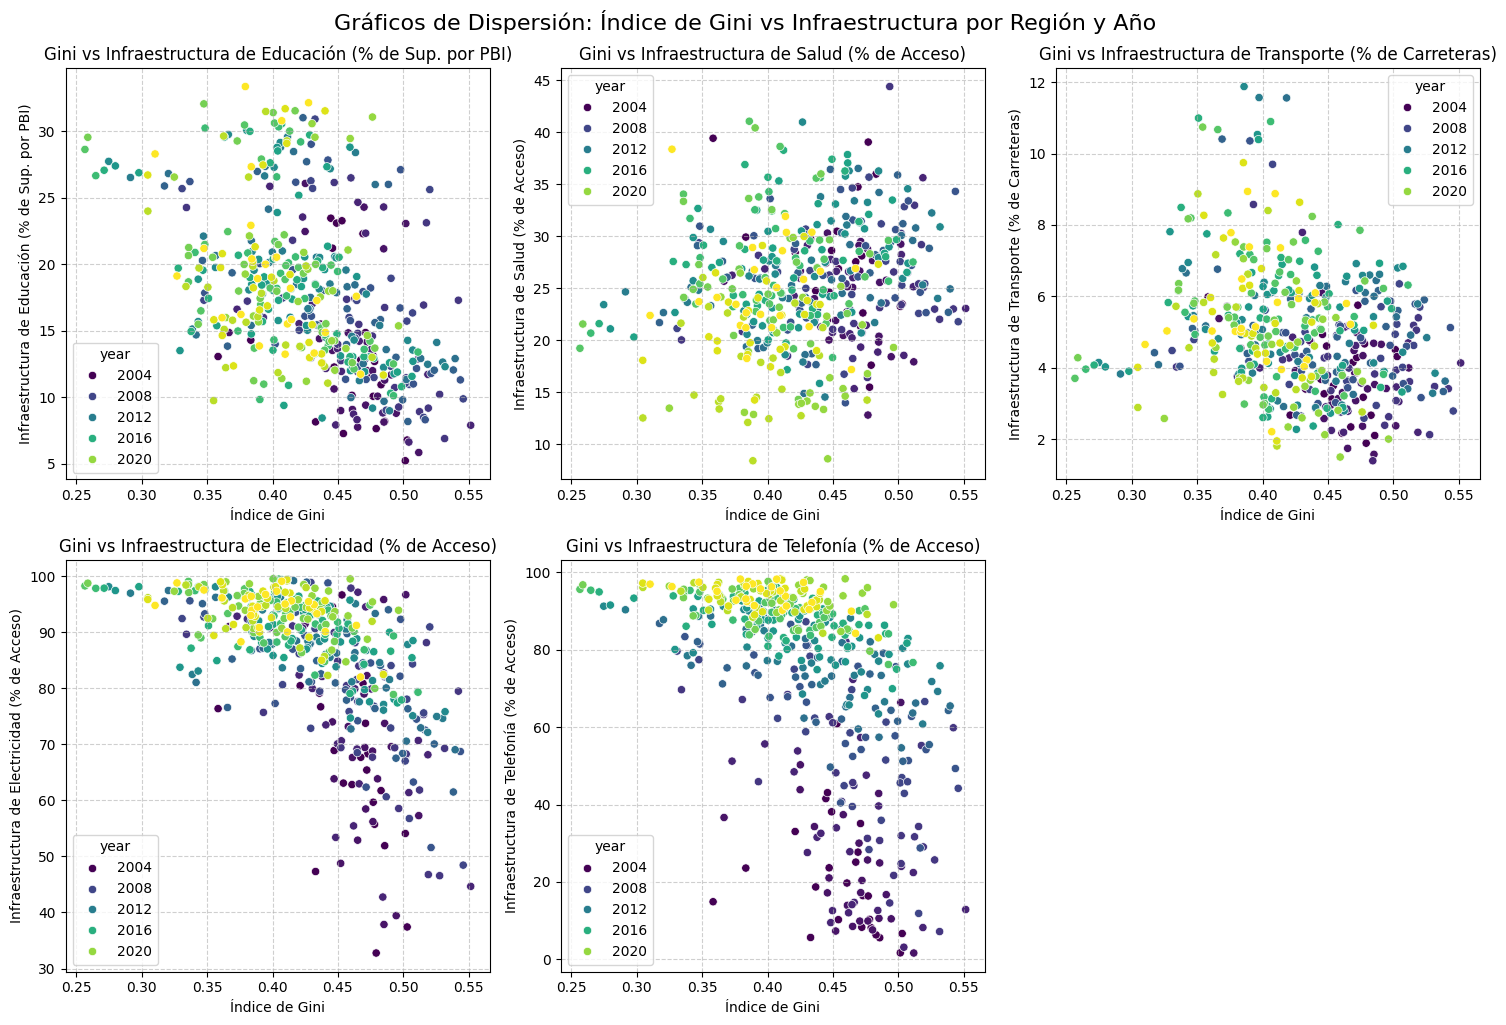

In [ ]:
# 17. Construcción de Gráficos de Dispersión

import matplotlib.pyplot as plt
import seaborn as sns

# Variables de infraestructura
infrastructure_vars = {
    'Educ': 'Infraestructura de Educación (% de Sup. por PBI)',
    'Salud': 'Infraestructura de Salud (% de Acceso)',
    'Infr': 'Infraestructura de Transporte (% de Carreteras)',
    'Elect': 'Infraestructura de Electricidad (% de Acceso)',
    'Telf': 'Infraestructura de Telefonía (% de Acceso)'
}

plt.figure(figsize=(15, 10))

for i, (col, title) in enumerate(infrastructure_vars.items()):
    plt.subplot(2, 3, i + 1) # 2 filas, 3 columnas para los subplots
    sns.scatterplot(x='Gini', y=col, data=df_merged, hue='year', palette='viridis', legend='brief')
    plt.title(f'Gini vs {title}')
    plt.xlabel('Índice de Gini')
    plt.ylabel(title)
    plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.suptitle('Gráficos de Dispersión: Índice de Gini vs Infraestructura por Región y Año', y=1.02, fontsize=16)
plt.show()

In [ ]:
# 18. Convocar librerias para regresiones
!pip install linearmodels
print("Librería 'linearmodels' instalada correctamente.")

Librería 'linearmodels' instalada correctamente.


In [ ]:
# 19. Ejecución de Regresión OLS

# Modelo Pooled OLS con errores corregidos para panel (PCSE)
from linearmodels.panel import PanelOLS

# 1. Crear el MultiIndex para el DataFrame de panel
df_panel = df_merged.set_index(['dpto', 'year'])

# Asegurarse de que la columna 'Y' esté presente en df_panel, copiándola de 'Gini'
df_panel['Y'] = df_panel['Gini']

# 2. Definir las variables dependiente e independiente
Y = df_panel['Y']  # 'Y' es la variable Gini renombrada

# Definir las variables independientes utilizando las listas predefinidas
xlist_full = ['lnpbi', 'lnpbi_sq', 'T_2020', 'schooling', 'Salud', 'ln_lineas', 'ln_poten', 'ln_km']
X = df_panel[xlist_full] # Se asume que quieres incluir todas estas variables como regresores

# --- FIX START ---
# Eliminar columnas duplicadas si existen. Esto es importante si la celda x3JXNMAmIm2Y se ejecutó varias veces.
X = X.loc[:, ~X.columns.duplicated()]

# Convertir variables dummy booleanas a enteros (0 o 1) ya que linearmodels espera tipos numéricos
for col in X.columns:
    if X[col].dtype == 'bool':
        X[col] = X[col].astype(int)
# --- FIX END ---

# Opcional: Si quieres añadir una constante al modelo, como es común en econometría
import statsmodels.api as sm
X = sm.add_constant(X, has_constant='add')

# 3. Ajustar el modelo PanelOLS con errores corregidos para panel (PCSE)
m1 = PanelOLS(Y, X).fit(cov_type='kernel', kernel='parzen')

# 4. Imprimir el resumen del modelo
print(m1.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:                      Y   R-squared:                        0.4477
Estimator:                   PanelOLS   R-squared (Between):              0.5246
No. Observations:                 480   R-squared (Within):               0.3325
Date:                Mon, Mar 23 2026   R-squared (Overall):              0.4477
Time:                        20:23:46   Log-likelihood                    862.52
Cov. Estimator:        Driscoll-Kraay                                           
                                        F-statistic:                      47.721
Entities:                          24   P-value                           0.0000
Avg Obs:                       20.000   Distribution:                   F(8,471)
Min Obs:                       20.000                                           
Max Obs:                       20.000   F-statistic (robust):             38.838
                            

In [ ]:
# 20. Ejecución de Regresión FGLS
# FGLS - Feasible Generalized Least Squares (aproximación con Random Effects de linearmodels)
from linearmodels.panel import RandomEffects

# Crear el modelo de Efectos Aleatorios
# RandomEffects es un tipo de estimador FGLS que asume que los efectos individuales
# son aleatorios y no correlacionados con los regresores.
m2 = RandomEffects(Y, X).fit(cov_type='robust') # 'robust' para errores estándar robustos

# Imprimir el resumen del modelo
print(m2.summary)

                        RandomEffects Estimation Summary                        
Dep. Variable:                      Y   R-squared:                        0.4279
Estimator:              RandomEffects   R-squared (Between):             -0.0717
No. Observations:                 480   R-squared (Within):               0.4483
Date:                Sun, Mar 22 2026   R-squared (Overall):              0.1366
Time:                        04:23:50   Log-likelihood                    1064.1
Cov. Estimator:                Robust                                           
                                        F-statistic:                      44.037
Entities:                          24   P-value                           0.0000
Avg Obs:                       20.000   Distribution:                   F(8,471)
Min Obs:                       20.000                                           
Max Obs:                       20.000   F-statistic (robust):             34.317
                            

In [ ]:
# 21. Ejecución de Regresión Fixed Effects

# Fixed Effects (Within Estimator)
from linearmodels.panel import PanelOLS

# Asegurarse de que X no tenga una constante si se usan efectos fijos
# PanelOLS con entity_effects=True agrega automáticamente la constante
X_fe = X.copy()
if 'const' in X_fe.columns:
    X_fe = X_fe.drop(columns=['const'])

# En linearmodels, entity_effects=True activa los Efectos Fijos
m4 = PanelOLS(Y, X_fe, entity_effects=True).fit(cov_type='clustered', cluster_entity=True)
print(m4.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:                      Y   R-squared:                        0.4578
Estimator:                   PanelOLS   R-squared (Between):             -1.4588
No. Observations:                 480   R-squared (Within):               0.4578
Date:                Sun, Mar 22 2026   R-squared (Overall):             -1.4468
Time:                        04:29:47   Log-likelihood                    1086.6
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      47.282
Entities:                          24   P-value                           0.0000
Avg Obs:                       20.000   Distribution:                   F(8,448)
Min Obs:                       20.000                                           
Max Obs:                       20.000   F-statistic (robust):             28.740
                            

In [ ]:
# 22. Ejecución de Regresión Random Effects

from linearmodels.panel import RandomEffects

# Crear el modelo de Efectos Aleatorios con errores estándar agrupados por entidad
# `cov_type='clustered'` y `cluster_entity=True` se utilizan para errores robustos agrupados por entidad.
# Para RandomEffects, `cov_type='clustered'` por sí solo agrupa por entidad por defecto si no se especifica `cluster_time`.
m6 = RandomEffects(Y, X).fit(cov_type='clustered', cluster_entity=True)

# Imprimir el resumen del modelo
print(m6.summary)

                        RandomEffects Estimation Summary                        
Dep. Variable:                      Y   R-squared:                        0.4279
Estimator:              RandomEffects   R-squared (Between):             -0.0717
No. Observations:                 480   R-squared (Within):               0.4483
Date:                Mon, Mar 23 2026   R-squared (Overall):              0.1366
Time:                        20:40:57   Log-likelihood                    1064.1
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      44.037
Entities:                          24   P-value                           0.0000
Avg Obs:                       20.000   Distribution:                   F(8,471)
Min Obs:                       20.000                                           
Max Obs:                       20.000   F-statistic (robust):             20.852
                            